Creating New Memories(without Duplication)

In [21]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [22]:
#1. LTM  Store Creation

store = InMemoryStore()

In [23]:
#2. LLMs
#    - memory_llm: extracts user memories and checks if each msg is NEW (no duplicate_of is  needed)
extractor_llm = ChatGoogleGenerativeAI(model  = "gemini-2.5-flash")

In [24]:
#Defining Pydantic model for the structured output from LLM as it should store in Memory LTM
class MemoryItem(BaseModel):
    text:str = Field(description="Atomic user memory as a short sentence")
    is_new :bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known")

In [36]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [34]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [26]:
memory_extractor = extractor_llm.with_structured_output(MemoryItem)


In [27]:
MEMORY_PROMPT = """
You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [28]:
def chat_creates_memory_node(state:MessagesState,config:RunnableConfig,store:BaseStore):
    user_id = config['configurable']['user_id']
    namespace = ("user",user_id,"details")
    
    #1. Loading Existing memories
    existing_items = store.search(namespace)
    existing_texts = [ item.value.get("data") for item in existing_items if item.value.get("data")]
    user_details_content = "\n".join(f"- {text} " for text in existing_texts ) if existing_texts else "(empty)"
    
    #2. Getting Recent User message
    last_message = state["messages"][-1]
    
    #3. LLM now extracts memories and checks if new or duplicate in existing memory
    decision : MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=(
                MEMORY_PROMPT.format(user_details_content=user_details_content),
                {"role":"user","content":f'USER MESSAGE :\n {last_message}'},
            ))
        ]
    )
    
    #4. Storing only new Memories 
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace,str(uuid.uuid4()),{"data":mem})
    
    return {"messages":[{"role":"assistant","content":"Noted"}]}

In [30]:

# 4) Build graph: START -> chat -> END
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

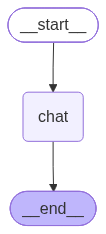

In [31]:
graph

In [32]:
config = {"configurable": {"user_id": "u1"}}

In [ ]:
result1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Nazia"}]}, config)
print("Assistant:", result1["messages"][-1].content)

In [ ]:
# Likely duplicate of the first memory -> is_new should be false -> saved=0
r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)

In [ ]:
for it in store.search(("user", "u1", "details")):
    print(it.value['data'])